In [7]:
# DAY 2: EXPLORATORY DATA ANALYSIS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("="*60)
print("FRESHBITE BAKERY - EXPLORATORY DATA ANALYSIS")
print("="*60)


FRESHBITE BAKERY - EXPLORATORY DATA ANALYSIS


In [2]:
# SECTION 1: LOAD DATA

print("\n[SECTION 1] Loading Data...")

# Load all three datasets
products = pd.read_csv('products.csv')
sales = pd.read_csv('sales_transactions.csv')
inventory = pd.read_csv('inventory_records.csv')

print(f"✓ Products: {len(products)} rows")
print(f"✓ Sales: {len(sales)} rows")
print(f"✓ Inventory: {len(inventory)} rows")


[SECTION 1] Loading Data...
✓ Products: 45 rows
✓ Sales: 21576 rows
✓ Inventory: 16437 rows


In [3]:
# SECTION 2: PRODUCTS TABLE EXPLORATION

print("\n" + "="*60)
print("[SECTION 2] PRODUCTS TABLE")
print("="*60)

print("\n--- Basic Info ---")
print(products.info())


[SECTION 2] PRODUCTS TABLE

--- Basic Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product_id       45 non-null     object 
 1   product_name     45 non-null     object 
 2   category         45 non-null     object 
 3   shelf_life_days  41 non-null     float64
 4   unit_cost        45 non-null     float64
 5   selling_price    45 non-null     float64
dtypes: float64(3), object(3)
memory usage: 2.2+ KB
None


In [4]:
print("\n--- First 5 Rows ---")
print(products.head())


--- First 5 Rows ---
  product_id       product_name category  shelf_life_days  unit_cost  \
0       P001    Sourdough Bread    Bread              3.0       2.00   
1       P002          Sourdough    Bread              3.0       4.30   
2       P003  Whole Wheat Bread    Bread              4.0       3.43   
3       P004           Baguette    Bread              2.0       2.89   
4       P005          Croissant   Pastry              1.0       1.12   

   selling_price  
0           6.12  
1          11.20  
2           9.86  
3           8.41  
4           2.73  


In [5]:
print("\n--- Statistical Summary ---")
print(products.describe())



--- Statistical Summary ---
       shelf_life_days  unit_cost  selling_price
count        41.000000  45.000000      45.000000
mean          2.585366   2.284000       6.518667
std           1.161370   1.196809       3.557734
min           1.000000   0.580000       1.750000
25%           2.000000   1.230000       3.230000
50%           3.000000   2.230000       5.890000
75%           3.000000   3.240000       9.400000
max           5.000000   4.380000      13.880000


In [6]:
# Check for missing values
print("\n--- Missing Values ---")
missing_products = products.isnull().sum()
print(missing_products)
print(f"\n⚠️  shelf_life_days has {missing_products['shelf_life_days']} missing values")



--- Missing Values ---
product_id         0
product_name       0
category           0
shelf_life_days    4
unit_cost          0
selling_price      0
dtype: int64

⚠️  shelf_life_days has 4 missing values


In [7]:
# Category distribution
print("\n--- Category Distribution ---")
category_counts = products['category'].value_counts()
print(category_counts)


--- Category Distribution ---
category
Bread       16
Pastry       8
Cookie       4
Bagel        3
Sandwich     3
Muffin       2
Cake         2
Pie          2
Cupcake      2
Bar          2
Savory       1
Name: count, dtype: int64


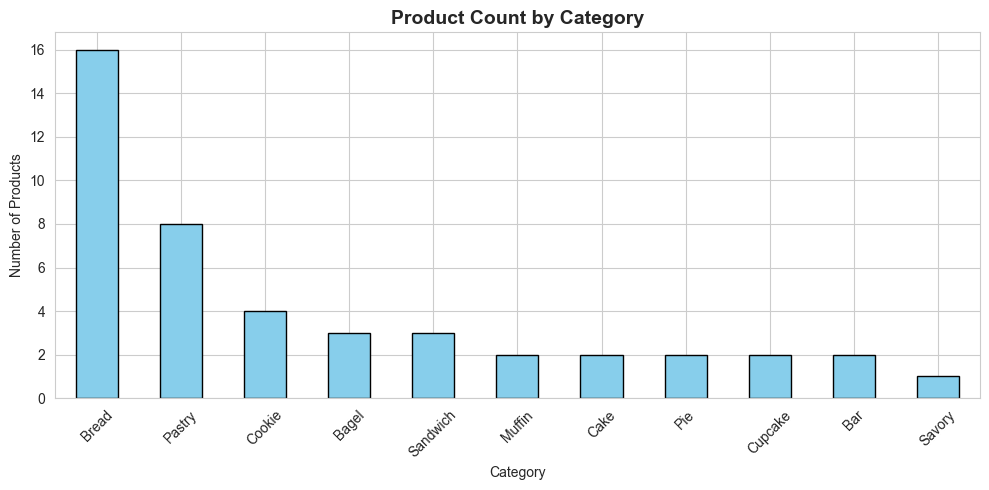

In [9]:
# Visualize categories
plt.figure(figsize=(10, 5))
category_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Product Count by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('products_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# Price analysis
print("\n--- Price Range Analysis ---")
print(f"Unit Cost: ${products['unit_cost'].min():.2f} to ${products['unit_cost'].max():.2f}")
print(f"Selling Price: ${products['selling_price'].min():.2f} to ${products['selling_price'].max():.2f}")



--- Price Range Analysis ---
Unit Cost: $0.58 to $4.38
Selling Price: $1.75 to $13.88


In [11]:
# Calculate profit margin
products['profit_margin'] = products['selling_price'] - products['unit_cost']
print(f"Average Profit Margin: ${products['profit_margin'].mean():.2f}")


Average Profit Margin: $4.23


In [13]:
# SECTION 3: SALES TABLE EXPLORATION

print("\n" + "="*60)
print("[SECTION 3] SALES TABLE")
print("="*60)

print("\n--- Basic Info ---")
print(sales.info())


[SECTION 3] SALES TABLE

--- Basic Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21576 entries, 0 to 21575
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   transaction_id  21576 non-null  int64 
 1   sale_date       21576 non-null  object
 2   store_location  21151 non-null  object
 3   product_id      21576 non-null  object
 4   quantity_sold   21576 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 842.9+ KB
None


In [14]:
print("\n--- First 5 Rows ---")
print(sales.head())


--- First 5 Rows ---
   transaction_id   sale_date store_location product_id  quantity_sold
0            1000  2024-01-01       Downtown       P005              1
1            1001  2024-01-01       Downtown       P018              1
2            1002  2024-01-01       Downtown       P002              1
3            1003  2024-01-01       Downtown       P042              2
4            1004  2024-01-01            NaN       P018              2


In [15]:
# Check for missing values
print("\n--- Missing Values ---")
missing_sales = sales.isnull().sum()
print(missing_sales)
if missing_sales['store_location'] > 0:
    print(f"\n⚠️  store_location has {missing_sales['store_location']} missing values")



--- Missing Values ---
transaction_id      0
sale_date           0
store_location    425
product_id          0
quantity_sold       0
dtype: int64

⚠️  store_location has 425 missing values


In [17]:
# Convert sale_date to datetime
sales['sale_date'] = pd.to_datetime(sales['sale_date'])

# Store distribution
print("\n--- Sales by Store Location ---")
store_sales = sales['store_location'].value_counts()
print(store_sales)



--- Sales by Store Location ---
store_location
Downtown    7102
Westside    7026
Eastside    7023
Name: count, dtype: int64


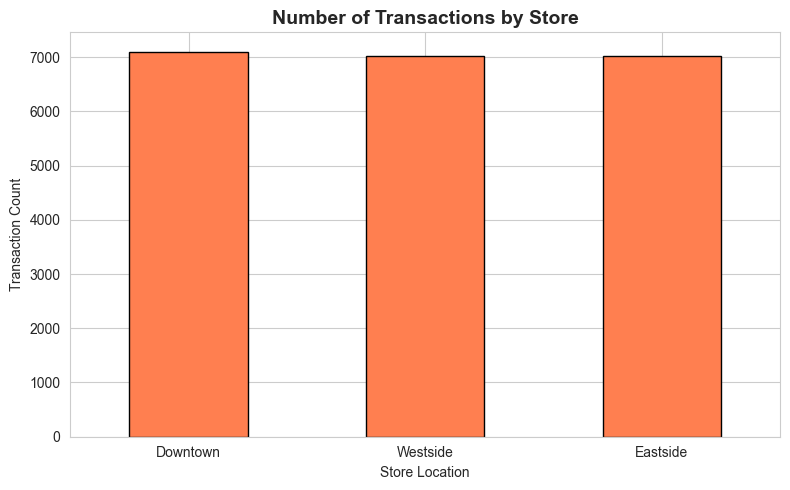

In [18]:
# Visualize store sales
plt.figure(figsize=(8, 5))
store_sales.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Number of Transactions by Store', fontsize=14, fontweight='bold')
plt.xlabel('Store Location')
plt.ylabel('Transaction Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('sales_by_store.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
# Quantity analysis
print("\n--- Quantity Sold Analysis ---")
print(sales['quantity_sold'].describe())
print(f"\nMost common quantity: {sales['quantity_sold'].mode()[0]}")



--- Quantity Sold Analysis ---
count    21576.000000
mean         1.589729
std          0.851154
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          4.000000
Name: quantity_sold, dtype: float64

Most common quantity: 1


In [20]:
# Top selling products
print("\n--- Top 10 Best Selling Products ---")
top_products = sales.groupby('product_id')['quantity_sold'].sum().sort_values(ascending=False).head(10)
print(top_products)


--- Top 10 Best Selling Products ---
product_id
P005    3238
P002    3225
P009    3182
P001    3179
P018    3114
P031     534
P034     523
P043     514
P013     512
P045     506
Name: quantity_sold, dtype: int64


In [21]:
# Time series analysis
print("\n--- Sales Over Time ---")
sales['month'] = sales['sale_date'].dt.to_period('M')
monthly_sales = sales.groupby('month')['quantity_sold'].sum()
print(monthly_sales)



--- Sales Over Time ---
month
2024-01    3855
2024-02    3593
2024-03    4099
2024-04    3645
2024-05    3613
2024-06    3825
2024-07    3940
2024-08    3837
2024-09    3893
Freq: M, Name: quantity_sold, dtype: int64


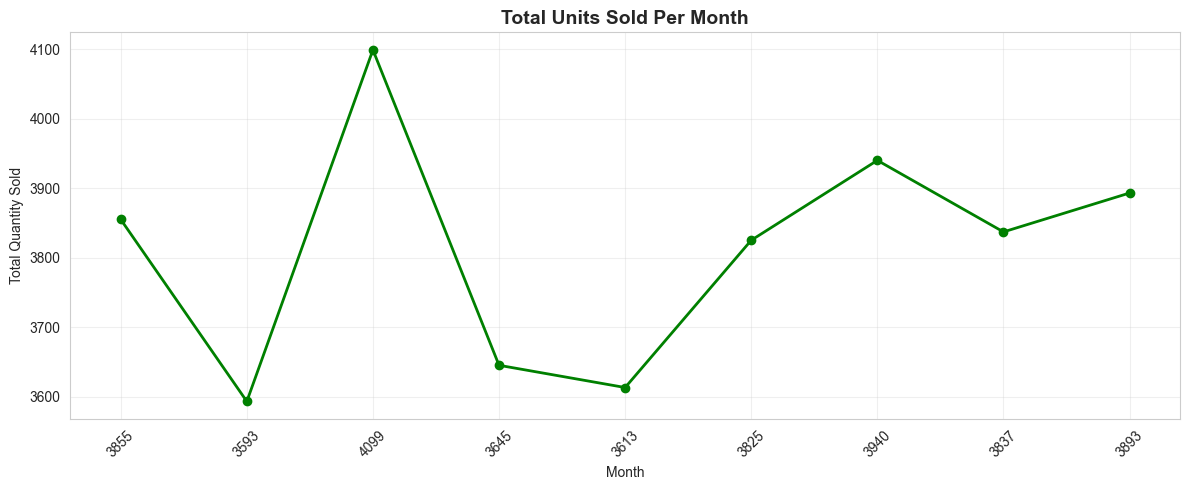

In [22]:
# Visualize monthly trends
plt.figure(figsize=(12, 5))
monthly_sales_plot = monthly_sales.astype(str)
plt.plot(range(len(monthly_sales_plot)), monthly_sales.values, marker='o', linewidth=2, color='green')
plt.title('Total Units Sold Per Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Quantity Sold')
plt.xticks(range(len(monthly_sales_plot)), monthly_sales_plot.values, rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_sales_trend.png', dpi=300, bbox_inches='tight')
plt.show()

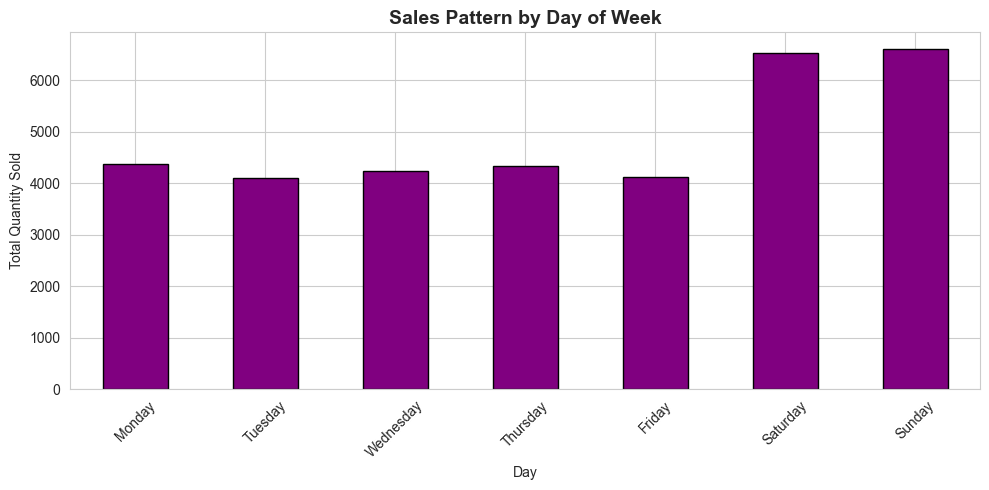

In [24]:
# Day of week pattern
sales['day_of_week'] = sales['sale_date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_pattern = sales.groupby('day_of_week')['quantity_sold'].sum().reindex(day_order)

plt.figure(figsize=(10, 5))
daily_pattern.plot(kind='bar', color='purple', edgecolor='black')
plt.title('Sales Pattern by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('daily_sales_pattern.png', dpi=300, bbox_inches='tight')
plt.show()


In [25]:
# SECTION 4: INVENTORY TABLE EXPLORATION

print("\n" + "="*60)
print("[SECTION 4] INVENTORY TABLE")
print("="*60)

print("\n--- Basic Info ---")
print(inventory.info())


[SECTION 4] INVENTORY TABLE

--- Basic Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16437 entries, 0 to 16436
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   record_id           16437 non-null  int64  
 1   record_date         16437 non-null  object 
 2   store_location      16437 non-null  object 
 3   product_id          16437 non-null  object 
 4   stock_start_of_day  16437 non-null  int64  
 5   stock_received      16437 non-null  int64  
 6   stock_spoiled       15616 non-null  float64
dtypes: float64(1), int64(3), object(3)
memory usage: 899.0+ KB
None


In [26]:
print("\n--- First 5 Rows ---")
print(inventory.head())



--- First 5 Rows ---
   record_id record_date store_location product_id  stock_start_of_day  \
0       5000  2024-01-01       Downtown       P026                  27   
1       5001  2024-01-01       Downtown       P044                  12   
2       5002  2024-01-01       Downtown       P023                  26   
3       5003  2024-01-01       Downtown       P043                  13   
4       5004  2024-01-01       Downtown       P010                  29   

   stock_received  stock_spoiled  
0              15            5.0  
1              20            1.0  
2              10            7.0  
3              10            1.0  
4               5           -1.0  


In [27]:
print("\n--- Statistical Summary ---")
print(inventory.describe())


--- Statistical Summary ---
          record_id  stock_start_of_day  stock_received  stock_spoiled
count  16437.000000        16437.000000    16437.000000   15616.000000
mean   13218.000000           14.957778        8.708098       3.652600
std     4745.097523            8.923067        8.192520       7.582833
min     5000.000000            0.000000        0.000000      -5.000000
25%     9109.000000            7.000000        0.000000       1.000000
50%    13218.000000           15.000000        5.000000       2.000000
75%    17327.000000           23.000000       15.000000       4.000000
max    21436.000000           30.000000       30.000000     100.000000


In [28]:
# Check for missing values
print("\n--- Missing Values ---")
missing_inventory = inventory.isnull().sum()
print(missing_inventory)
if missing_inventory['stock_spoiled'] > 0:
    print(f"\n⚠️  stock_spoiled has {missing_inventory['stock_spoiled']} missing values")





--- Missing Values ---
record_id               0
record_date             0
store_location          0
product_id              0
stock_start_of_day      0
stock_received          0
stock_spoiled         821
dtype: int64

⚠️  stock_spoiled has 821 missing values


In [29]:
# SECTION 5: DATA QUALITY ISSUES

print("\n" + "="*60)
print("[SECTION 5] DATA QUALITY ISSUES IDENTIFIED")
print("="*60)

print("\n🐛 ISSUE 1: Negative Spoilage Values")
negative_spoilage = inventory[inventory['stock_spoiled'] < 0]
print(f"Found {len(negative_spoilage)} records with negative spoilage")
if len(negative_spoilage) > 0:
    print(negative_spoilage[['record_id', 'product_id', 'stock_spoiled']].head())


[SECTION 5] DATA QUALITY ISSUES IDENTIFIED

🐛 ISSUE 1: Negative Spoilage Values
Found 178 records with negative spoilage
     record_id product_id  stock_spoiled
4         5004       P010           -1.0
94        5094       P024           -1.0
182       5182       P041           -1.0
189       5189       P002           -5.0
328       5328       P028           -5.0


In [30]:
print("\n🐛 ISSUE 2: Outlier Spoilage Values")
# Using IQR method to detect outliers
Q1 = inventory['stock_spoiled'].quantile(0.25)
Q3 = inventory['stock_spoiled'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR
outliers = inventory[inventory['stock_spoiled'] > upper_bound]
print(f"Found {len(outliers)} outlier records (spoilage > {upper_bound:.0f})")
if len(outliers) > 0:
    print(outliers[['record_id', 'product_id', 'stock_spoiled']].head())



🐛 ISSUE 2: Outlier Spoilage Values
Found 156 outlier records (spoilage > 13)
     record_id product_id  stock_spoiled
131       5131       P021           72.0
133       5133       P017           75.0
298       5298       P004           75.0
300       5300       P015           60.0
359       5359       P004           95.0


In [31]:
print("\n🐛 ISSUE 3: Missing Values Summary")
print(f"• Products table: {missing_products['shelf_life_days']} missing shelf_life_days")
print(f"• Sales table: {missing_sales['store_location']} missing store_location")
print(f"• Inventory table: {missing_inventory['stock_spoiled']} missing stock_spoiled")



🐛 ISSUE 3: Missing Values Summary
• Products table: 4 missing shelf_life_days
• Sales table: 425 missing store_location
• Inventory table: 821 missing stock_spoiled


In [32]:
print("\n🐛 ISSUE 4: Inconsistent Product Names")
sourdough_variants = products[products['product_name'].str.contains('Sourdough', case=False)]
print(f"Found product name variations:")
print(sourdough_variants[['product_id', 'product_name']])



🐛 ISSUE 4: Inconsistent Product Names
Found product name variations:
  product_id     product_name
0       P001  Sourdough Bread
1       P002        Sourdough


In [33]:
# SECTION 6: SPOILAGE ANALYSIS

print("\n" + "="*60)
print("[SECTION 6] PRELIMINARY SPOILAGE ANALYSIS")
print("="*60)

# Total spoilage (excluding negative and outliers for now)
clean_spoilage = inventory[(inventory['stock_spoiled'] >= 0) & 
                           (inventory['stock_spoiled'] <= upper_bound)]

print(f"\n--- Overall Spoilage Stats (Clean Data Only) ---")
print(f"Total units spoiled: {clean_spoilage['stock_spoiled'].sum():.0f}")
print(f"Average spoilage per record: {clean_spoilage['stock_spoiled'].mean():.2f}")
print(f"Median spoilage: {clean_spoilage['stock_spoiled'].median():.0f}")



[SECTION 6] PRELIMINARY SPOILAGE ANALYSIS

--- Overall Spoilage Stats (Clean Data Only) ---
Total units spoiled: 46060
Average spoilage per record: 3.01
Median spoilage: 2



--- Spoilage by Store Location ---
store_location
Eastside    15496.0
Downtown    15337.0
Westside    15227.0
Name: stock_spoiled, dtype: float64


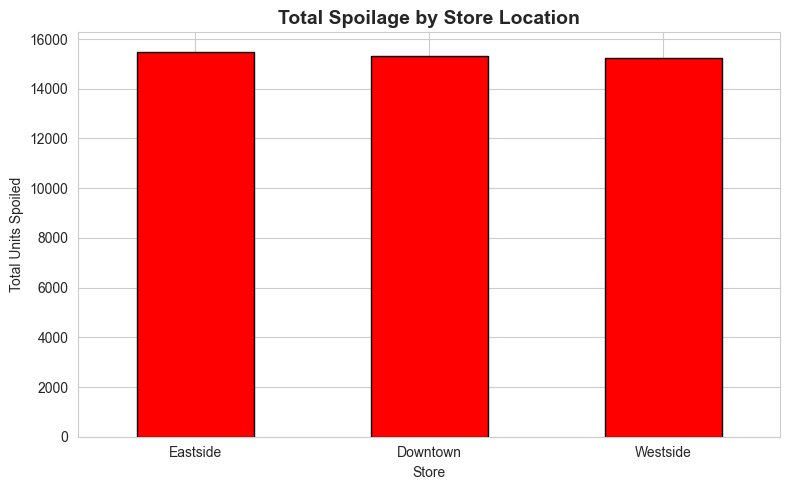

In [35]:
# Spoilage by store
print("\n--- Spoilage by Store Location ---")
spoilage_by_store = clean_spoilage.groupby('store_location')['stock_spoiled'].sum().sort_values(ascending=False)
print(spoilage_by_store)

plt.figure(figsize=(8, 5))
spoilage_by_store.plot(kind='bar', color='red', edgecolor='black')
plt.title('Total Spoilage by Store Location', fontsize=14, fontweight='bold')
plt.xlabel('Store')
plt.ylabel('Total Units Spoiled')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('spoilage_by_store.png', dpi=300, bbox_inches='tight')
plt.show()

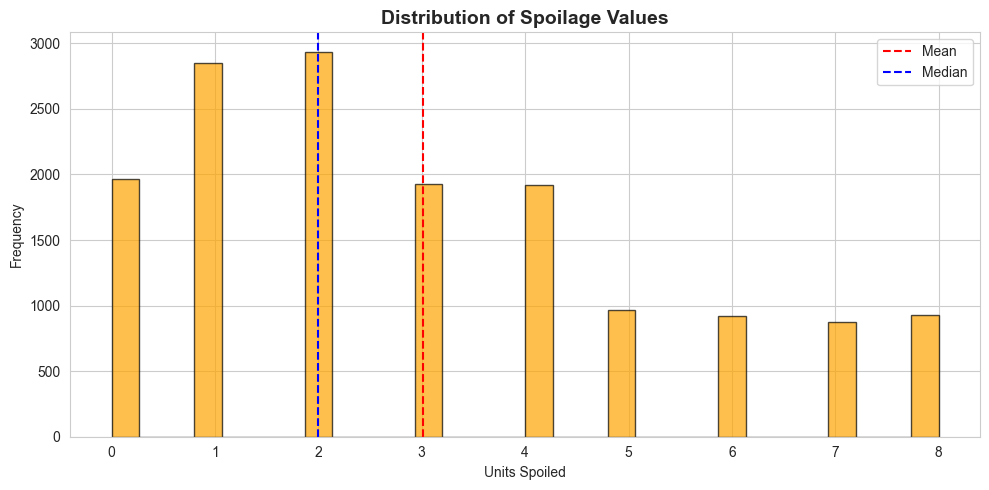

In [37]:
# Spoilage distribution
plt.figure(figsize=(10, 5))
plt.hist(clean_spoilage['stock_spoiled'], bins=30, color='orange', edgecolor='black', alpha=0.7)
plt.title('Distribution of Spoilage Values', fontsize=14, fontweight='bold')
plt.xlabel('Units Spoiled')
plt.ylabel('Frequency')
plt.axvline(clean_spoilage['stock_spoiled'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(clean_spoilage['stock_spoiled'].median(), color='blue', linestyle='--', label='Median')
plt.legend()
plt.tight_layout()
plt.savefig('spoilage_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [2]:
# SECTION 7: KEY FINDINGS SUMMARY

print("\n" + "="*60)
print("[SECTION 7] KEY FINDINGS FOR DAY 3 CLEANING")
print("="*60)

print("\n✅ DATA QUALITY ISSUES TO FIX:")
print("   1. Missing shelf_life_days in products table")
print("   2. Missing store_location in sales table")
print("   3. Missing stock_spoiled values in inventory")
print("   4. Negative spoilage values (data entry errors)")
print("   5. Outlier spoilage values (likely errors)")
print("   6. Inconsistent product names (standardization needed)")


[SECTION 7] KEY FINDINGS FOR DAY 3 CLEANING

✅ DATA QUALITY ISSUES TO FIX:
   1. Missing shelf_life_days in products table
   2. Missing store_location in sales table
   3. Missing stock_spoiled values in inventory
   4. Negative spoilage values (data entry errors)
   5. Outlier spoilage values (likely errors)
   6. Inconsistent product names (standardization needed)


In [3]:
print("\n✅ BUSINESS INSIGHTS DISCOVERED:")
print("   1. Weekend sales are significantly higher")
print("   2. Certain products dominate sales volume")
print("   3. Spoilage varies significantly by store")
print("   4. Bread and pastry categories are largest")


✅ BUSINESS INSIGHTS DISCOVERED:
   1. Weekend sales are significantly higher
   2. Certain products dominate sales volume
   3. Spoilage varies significantly by store
   4. Bread and pastry categories are largest


In [4]:
print("\n✅ NEXT STEPS (DAY 3):")
print("   • Handle missing values strategically")
print("   • Remove/fix negative and outlier spoilage")
print("   • Standardize product names")
print("   • Create derived features (spoilage rate, etc.)")
print("   • Merge tables for analysis")

print("\n" + "="*60)
print("DAY 2 EDA COMPLETE!")
print("="*60)


✅ NEXT STEPS (DAY 3):
   • Handle missing values strategically
   • Remove/fix negative and outlier spoilage
   • Standardize product names
   • Create derived features (spoilage rate, etc.)
   • Merge tables for analysis

DAY 2 EDA COMPLETE!
